<a href="https://colab.research.google.com/github/rupeshjajedy-jpg/English_to_French_RNN_Project/blob/main/English_to_French_RNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Continuous Assessment - 3
# Project: Language Translation using Vanilla RNN
# English to French Translation
# ============================================================


# STEP 1: Import the pair of data provided for model training

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy



In [ ]:
# load dataset
data = pd.read_csv("eng_-french.csv")

In [ ]:
# STEP 2: Encode the dataset

def clean_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-ZÀ-ÿ?.!,¿]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

# Extract English and French texts from the DataFrame
english_texts = data["English words/sentences"].astype(str)
french_texts = data["French words/sentences"].astype(str)

english_texts = english_texts.apply(clean_sentence)
french_texts = french_texts.apply(clean_sentence)


In [ ]:
# Using smaller data for faster training
english_texts = english_texts[:30000]
french_texts = french_texts[:30000]

In [ ]:
# Tokenizers
english_tokenizer = Tokenizer()
english_tokenizer.fit_on_texts(english_texts)

french_tokenizer = Tokenizer()
french_tokenizer.fit_on_texts(french_texts)

english_vocab_size = len(english_tokenizer.word_index) + 1
french_vocab_size = len(french_tokenizer.word_index) + 1

print("English Vocabulary Size:", english_vocab_size)
print("French Vocabulary Size:", french_vocab_size)

english_sequences = english_tokenizer.texts_to_sequences(english_texts)
french_sequences = french_tokenizer.texts_to_sequences(french_texts)




English Vocabulary Size: 4344
French Vocabulary Size: 7902


In [ ]:
# STEP 3: Convert it into X, Y

max_english_len = max(len(seq) for seq in english_sequences)
max_french_len = max(len(seq) for seq in french_sequences)

max_len = max(max_english_len, max_french_len)

X = pad_sequences(english_sequences, maxlen=max_len, padding="post")
Y = pad_sequences(french_sequences, maxlen=max_len, padding="post")

Y = Y.reshape(Y.shape[0], Y.shape[1], 1)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (24000, 14)
Y_train shape: (24000, 14, 1)
X_test shape: (6000, 14)
Y_test shape: (6000, 14, 1)


In [ ]:
# STEP 4: Design Model

model = Sequential()

model.add(Embedding(
    input_dim=english_vocab_size,
    output_dim=128,
    input_length=max_len
))

model.add(SimpleRNN(
    units=256,
    return_sequences=True
))

model.add(TimeDistributed(Dense(
    french_vocab_size,
    activation="softmax"
)))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=sparse_categorical_crossentropy,
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# STEP 5: Summarize the model

print("\nModel Summary:")
model.summary()


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 6: Model Training

history = model.fit(
    X_train,
    Y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 130s 426ms/step - accuracy: 0.7127 - loss: 2.3168 - val_accuracy: 0.7361 - val_loss: 1.8015
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 416ms/step - accuracy: 0.7551 - loss: 1.6397 - val_accuracy: 0.7599 - val_loss: 1.6011
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 117s 391ms/step - accuracy: 0.7726 - loss: 1.4531 - val_accuracy: 0.7715 - val_loss: 1.4863
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 118s 395ms/step - accuracy: 0.7829 - loss: 1.3120 - val_accuracy: 0.7790 - val_loss: 1.4075
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 122s 408ms/step - accuracy: 0.7901 - loss: 1.1975 - val_accuracy: 0.7856 - val_loss: 1.3481
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 128s 426ms/step - accuracy: 0.7970 - loss: 1.1002 - val_accuracy: 0.7888 - val_loss: 1.3037
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 118s 394ms/step - accuracy: 0.8032 - loss: 1.0163 - val_accuracy: 0.7937 - val_loss: 1.2659
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 141s 392ms/step - accuracy: 0.8097 -

In [ ]:
# STEP 7: Clean the English corpus for testing

def prepare_input_sentence(sentence):
    sentence = clean_sentence(sentence)
    sequence = english_tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(sequence, maxlen=max_len, padding="post")
    return padded


test_sentence = "how are you"
cleaned_test = clean_sentence(test_sentence)

print("Original Sentence:", test_sentence)
print("Cleaned Sentence:", cleaned_test)

Original Sentence: how are you
Cleaned Sentence: how are you


In [ ]:
# STEP 8: Feed English corpus for Evaluation and Inference

test_input = prepare_input_sentence(test_sentence)

prediction = model.predict(test_input)

print("Prediction shape:", prediction.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Prediction shape: (1, 14, 7902)


In [ ]:
# STEP 9: Decode the output

reverse_french_word_index = {
    index: word for word, index in french_tokenizer.word_index.items()
}

def decode_prediction(prediction):
    predicted_ids = np.argmax(prediction, axis=-1)[0]
    translated_words = []

    for word_id in predicted_ids:
        if word_id == 0:
            continue
        word = reverse_french_word_index.get(word_id, "")
        translated_words.append(word)

    return " ".join(translated_words)


translated_sentence = decode_prediction(prediction)

print("English Sentence:", test_sentence)
print("Predicted French Translation:", translated_sentence)

English Sentence: how are you
Predicted French Translation: comment allez vous


In [ ]:
# More Testing Examples

test_examples = [
    "hi",
    "run",
    "i am happy",
    "how are you",
    "thank you",
    "i love you",
    "where are you"
]

print("\nTesting on English Sentences:")
for sentence in test_examples:
    test_input = prepare_input_sentence(sentence)
    prediction = model.predict(test_input, verbose=0)
    translation = decode_prediction(prediction)

    print("English:", sentence)
    print("French Prediction:", translation)
    print("-" * 40)


Testing on English Sentences:
English: hi
French Prediction: salut
----------------------------------------
English: run
French Prediction: 
----------------------------------------
English: i am happy
French Prediction: je suis heureux
----------------------------------------
English: how are you
French Prediction: comment allez vous
----------------------------------------
English: thank you
French Prediction: merci bien
----------------------------------------
English: i love you
French Prediction: je adore aime
----------------------------------------
English: where are you
French Prediction: où sont vous
----------------------------------------


In [ ]:
# STEP 10: Calculate the Loss on test dataset

test_loss, test_accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.8020 - loss: 1.1879
Test Loss: 1.1878777742385864
Test Accuracy: 0.8019999265670776


In [ ]:
# STEP 11: Optimize the model parameters to minimize the loss

optimized_model = Sequential()

optimized_model.add(Embedding(
    input_dim=english_vocab_size,
    output_dim=256,
    input_length=max_len
))

optimized_model.add(SimpleRNN(
    units=512,
    return_sequences=True,
    dropout=0.2
))

optimized_model.add(TimeDistributed(Dense(
    french_vocab_size,
    activation="softmax"
)))
optimized_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=sparse_categorical_crossentropy,
    metrics=["accuracy"]
)

print("\nOptimized Model Summary:")
optimized_model.summary()

optimized_history = optimized_model.fit(
    X_train,
    Y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)
optimized_loss, optimized_accuracy = optimized_model.evaluate(X_test, Y_test)

print("Optimized Test Loss:", optimized_loss)
print("Optimized Test Accuracy:", optimized_accuracy)



Optimized Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 205s 677ms/step - accuracy: 0.7112 - loss: 2.3466 - val_accuracy: 0.7320 - val_loss: 1.8400
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 200s 666ms/step - accuracy: 0.7485 - loss: 1.6880 - val_accuracy: 0.7559 - val_loss: 1.6610
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 208s 686ms/step - accuracy: 0.7658 - loss: 1.5180 - val_accuracy: 0.7656 - val_loss: 1.5504
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 198s 662ms/step - accuracy: 0.7766 - loss: 1.3834 - val_accuracy: 0.7736 - val_loss: 1.4680
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 192s 642ms/step - accuracy: 0.7839 - loss: 1.2729 - val_accuracy: 0.7789 - val_loss: 1.4064
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 190s 634ms/step - accuracy: 0.7889 - loss: 1.1791 - val_accuracy: 0.7837 - val_loss: 1.3575
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 196s 654ms/step - accuracy: 0.7945 - loss: 1.0935 - val_accuracy: 0.7873 - val_loss: 1.3152
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 203s 655ms/step - accuracy: 0.8004 -

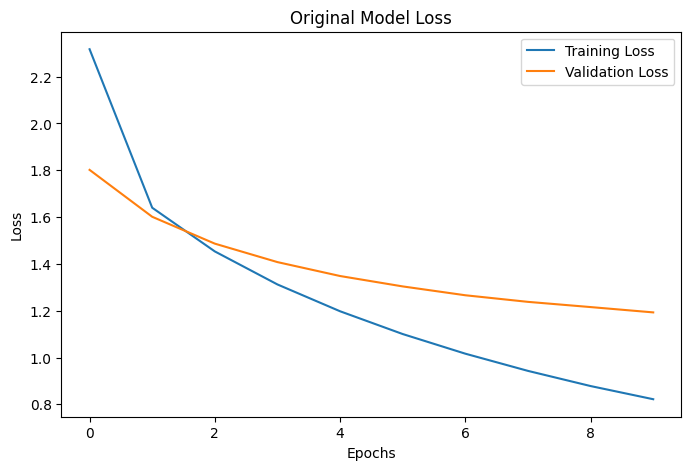

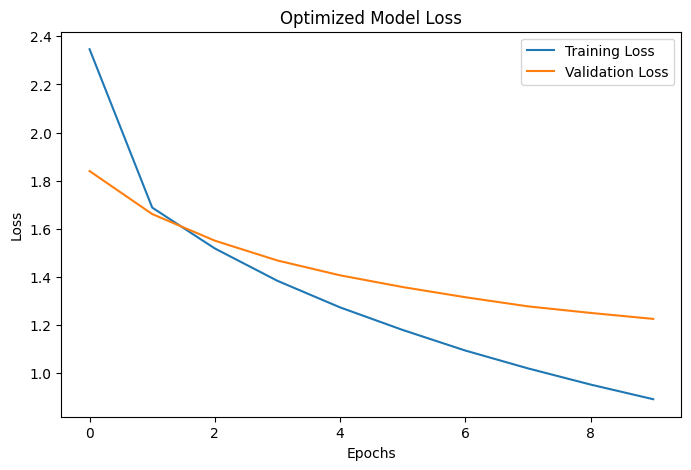

In [ ]:
# Visualization of Training Loss

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Original Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history["loss"], label="Training Loss")
plt.plot(optimized_history.history["val_loss"], label="Validation Loss")
plt.title("Optimized Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


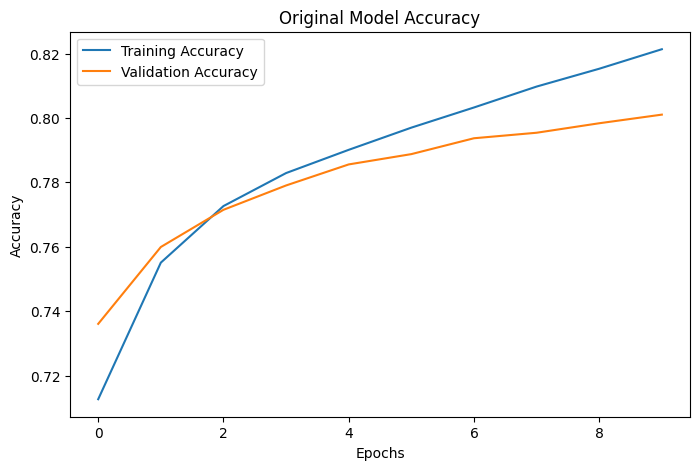

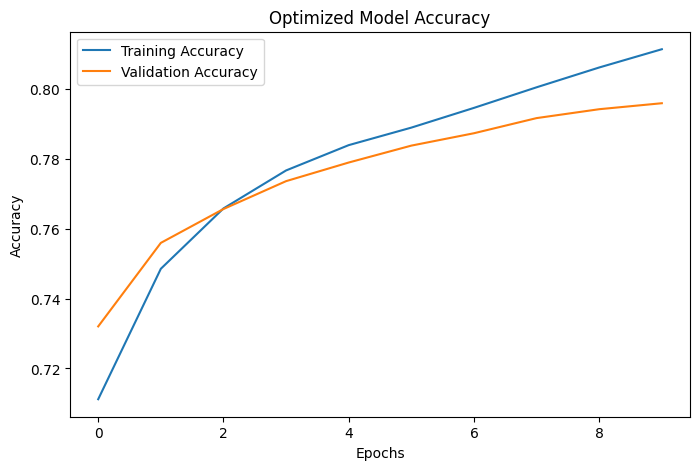

In [ ]:
# Visualization of Accuracy

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Original Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history["accuracy"], label="Training Accuracy")
plt.plot(optimized_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Optimized Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# STEP 12: Visualize the model in https://netron.app/

# Save model for Netron visualization
model.save("english_to_french_rnn_model.h5")
optimized_model.save("optimized_english_to_french_rnn_model.h5")

print("Model saved successfully.")
print("Open https://netron.app/")
print("Upload english_to_french_rnn_model.h5 or optimized_english_to_french_rnn_model.h5")
print("Take screenshot and attach it in your final ZIP file.")

Model saved successfully.
Open https://netron.app/
Upload english_to_french_rnn_model.h5 or optimized_english_to_french_rnn_model.h5
Take screenshot and attach it in your final ZIP file.


In [ ]:
from google.colab import files
files.download('english_to_french_rnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>